# **Day 36: Random Forest**
*Module 6 - Ensemble Learning*

Random Forest (Breiman, 2001) = **bagging + random feature selection at every split**. It is accurate, robust, needs little tuning, handles hundreds of features, gives OOB error and feature importance for free, and is the **most used classifier in remote sensing** (Belgiu & Dragut, 2016).

> A random forest is a bagged collection of decision trees, where each split may only consider a random subset of features. The trees become diverse, and their average is accurate and stable. It is the workhorse of remote-sensing classification.
>
> *Example:* 500 trees each vote on a pixel's class; if 420 say "forest", the forest probability is 0.84.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.inspection import permutation_importance
rng = np.random.default_rng(36)

## **1. The Algorithm**
For each of $B$ trees:
1. Draw a bootstrap sample of the training data.
2. Grow a tree; at **each split**, consider only a random subset of `max_features` (mtry) features, and choose the best split among them.
3. Grow deep (little or no pruning).
Predict by majority vote / probability average (classification) or mean (regression).

**Why the random features?** If one feature is very strong, every bagged tree splits on it first, and the trees are highly correlated. Restricting the candidates forces other features to be used, so the trees **decorrelate**, and averaging removes more variance.

In [2]:
from sklearn.datasets import make_classification
X, y = make_classification(3000, 40, n_informative=8, n_redundant=12, n_repeated=0, class_sep=0.8, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)
for name, m in {"single tree": DecisionTreeClassifier(random_state=0),
                "bagged trees (mtry = all 40)": BaggingClassifier(DecisionTreeClassifier(), n_estimators=300, random_state=0, n_jobs=-1),
                "random forest (mtry = sqrt(40) = 6)": RandomForestClassifier(300, max_features="sqrt", random_state=0, n_jobs=-1)}.items():
    m.fit(X_tr, y_tr); print(f"{name:<36} test accuracy {m.score(X_te, y_te):.3f}")

single tree                          test accuracy 0.843


bagged trees (mtry = all 40)         test accuracy 0.899


random forest (mtry = sqrt(40) = 6)  test accuracy 0.903


## **2. Hyperparameters**

| Parameter | Default (sklearn) | Effect | Typical tuning |
|---|---|---|---|
| `n_estimators` | 100 | More trees = more stable; never overfits, only slower | 300-1000; check OOB curve |
| `max_features` (mtry) | `"sqrt"` (clf), `1.0` (reg) | Lower = more decorrelation, more bias | sqrt(p), p/3, log2(p), 0.2-0.5 |
| `min_samples_leaf` | 1 | Larger = smoother, better probabilities | 1-10 |
| `max_depth` | None | Limits complexity | usually None |
| `max_samples` | full bootstrap | Smaller = faster, more diverse | 0.5-1.0 |
| `class_weight` | None | Imbalance (Day 21) | `"balanced_subsample"` |

RF is famous for working well with defaults (Probst et al., 2019): tuning usually gives modest gains, mostly from `max_features` and `min_samples_leaf`.

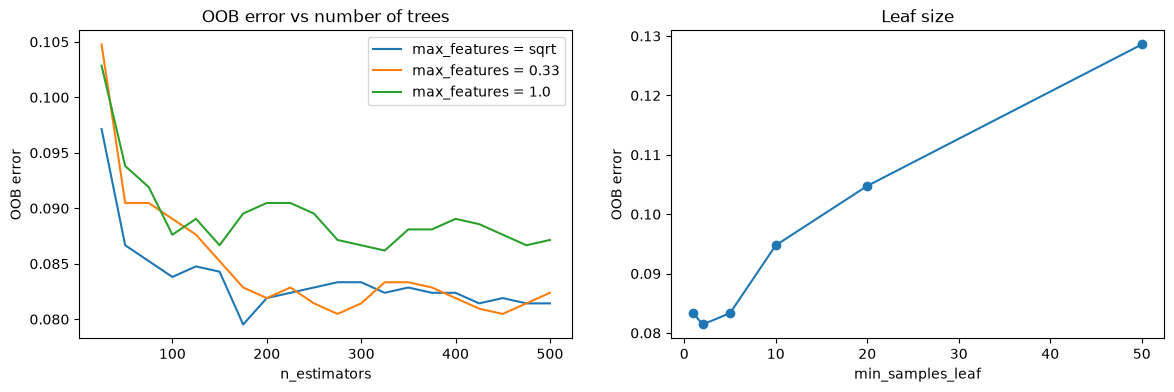

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for mf in ["sqrt", 0.33, 1.0]:
    errs = []
    rf = RandomForestClassifier(warm_start=True, max_features=mf, oob_score=True, random_state=0, n_jobs=-1)
    for n_est in range(25, 501, 25):
        rf.set_params(n_estimators=n_est); rf.fit(X_tr, y_tr); errs.append(1 - rf.oob_score_)
    axes[0].plot(range(25, 501, 25), errs, label=f"max_features = {mf}")
axes[0].set(xlabel="n_estimators", ylabel="OOB error", title="OOB error vs number of trees"); axes[0].legend()
leafs = [1, 2, 5, 10, 20, 50]
axes[1].plot(leafs, [1 - RandomForestClassifier(300, min_samples_leaf=l, oob_score=True, random_state=0, n_jobs=-1).fit(X_tr, y_tr).oob_score_ for l in leafs], "o-")
axes[1].set(xlabel="min_samples_leaf", ylabel="OOB error", title="Leaf size")
plt.show()

## **3. Random Forest Regression**

In [4]:
n = 1500
Xr = pd.DataFrame({"ndvi": rng.uniform(0.1, 0.9, n), "elevation": rng.uniform(100, 2500, n), "slope": rng.uniform(0, 45, n),
                   "rain": rng.uniform(800, 3000, n), "dist_road": rng.exponential(2, n)})
agb = (300 * Xr.ndvi ** 2 * (1 + 0.0002 * Xr.rain) - 0.03 * (Xr.elevation - 1200).abs() / 10 + 10 * np.log1p(Xr.dist_road)
       + rng.normal(0, 15, n)).clip(0)                                  # above-ground biomass (t/ha)
rfr = RandomForestRegressor(500, min_samples_leaf=2, oob_score=True, random_state=0, n_jobs=-1).fit(Xr, agb)
print(f"RF regression OOB R2 = {rfr.oob_score_:.3f} | 5-fold CV R2 = {cross_val_score(RandomForestRegressor(300, random_state=0, n_jobs=-1), Xr, agb, cv=5).mean():.3f}")

RF regression OOB R2 = 0.974 | 5-fold CV R2 = 0.973


## **4. Feature Importance**
- **MDI (mean decrease in impurity)**: `feature_importances_`. Free, but biased towards continuous / high-cardinality features and computed on training data.
- **Permutation importance**: drop in score when a feature's values are shuffled on **held-out** data. Unbiased, model-agnostic, slower.
- **Correlated features share importance**: if two features carry the same information, each looks less important than it is (and permuting one is compensated by the other).

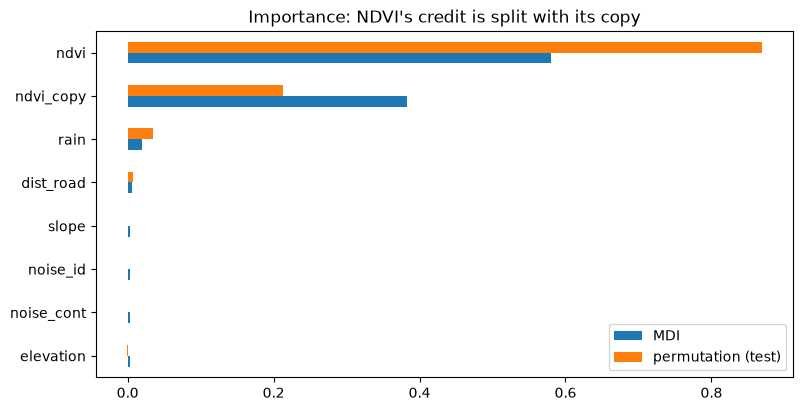

In [5]:
Xr2 = Xr.assign(ndvi_copy=Xr.ndvi + rng.normal(0, 0.01, n), noise_cont=rng.normal(size=n), noise_id=rng.permutation(n))
Xa, Xb, ya, yb = train_test_split(Xr2, agb, random_state=0)
rf2 = RandomForestRegressor(500, random_state=0, n_jobs=-1).fit(Xa, ya)
perm = permutation_importance(rf2, Xb, yb, n_repeats=15, random_state=0, n_jobs=-1)
imp = pd.DataFrame({"MDI": rf2.feature_importances_, "permutation (test)": perm.importances_mean}, index=Xr2.columns)
imp.sort_values("permutation (test)").plot.barh(figsize=(9, 4.5), title="Importance: NDVI's credit is split with its copy")
plt.show()

**Remedies** for correlated features: group them and permute together (grouped permutation importance), drop-column importance, conditional importance, or SHAP with care (Day 45).

## **5. Extremely Randomized Trees (ExtraTrees)**
ExtraTrees choose split **thresholds at random** (for each candidate feature) and use the whole sample (no bootstrap by default). Even more variance reduction, faster training; sometimes more accurate on noisy data.

In [6]:
for name, m in {"Random Forest": RandomForestClassifier(500, random_state=0, n_jobs=-1),
                "Extra Trees": ExtraTreesClassifier(500, random_state=0, n_jobs=-1)}.items():
    import time; t = time.perf_counter()
    s = cross_val_score(m, X, y, cv=5).mean()
    print(f"{name:<14} CV accuracy {s:.3f} ({time.perf_counter() - t:.1f}s)")

Random Forest  CV accuracy 0.923 (3.9s)


Extra Trees    CV accuracy 0.926 (2.5s)


# **Part 2: Going Deeper**

### A remote-sensing style example: 6-class land cover from 10 spectral bands + indices
Sentinel-2-like reflectances (B2-B12) for six classes, with within-class variability and spectral overlap (crop vs grassland, urban vs bare soil).

OOB accuracy 0.970 | test accuracy 0.975

              precision    recall  f1-score   support

   bare_soil      0.948     0.908     0.928       120
    cropland      0.992     1.000     0.996       120
      forest      1.000     1.000     1.000       120
   grassland      1.000     0.992     0.996       120
       urban      0.912     0.950     0.931       120
       water      1.000     1.000     1.000       120

    accuracy                          0.975       720
   macro avg      0.975     0.975     0.975       720
weighted avg      0.975     0.975     0.975       720



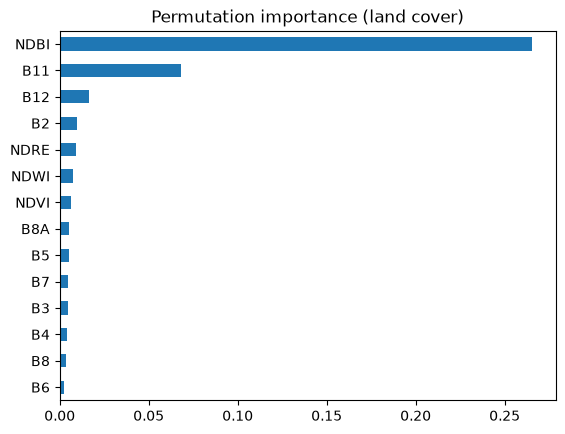

In [7]:
bands = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
mean_spectra = {"water": [0.06, 0.05, 0.03, 0.03, 0.02, 0.02, 0.02, 0.02, 0.01, 0.01],
                "forest": [0.03, 0.05, 0.03, 0.08, 0.22, 0.28, 0.32, 0.33, 0.16, 0.08],
                "cropland": [0.05, 0.08, 0.06, 0.12, 0.25, 0.30, 0.34, 0.35, 0.22, 0.13],
                "grassland": [0.06, 0.09, 0.08, 0.13, 0.22, 0.26, 0.29, 0.30, 0.25, 0.16],
                "urban": [0.10, 0.11, 0.12, 0.14, 0.16, 0.17, 0.18, 0.19, 0.22, 0.20],
                "bare_soil": [0.11, 0.13, 0.16, 0.18, 0.20, 0.21, 0.22, 0.23, 0.30, 0.26]}
rows = []
for c, s in mean_spectra.items():
    s = np.array(s)
    for _ in range(400):
        rows.append(list(s * rng.uniform(0.8, 1.2) + rng.normal(0, 0.012, 10)) + [c])
lc = pd.DataFrame(rows, columns=bands + ["cls"])
lc["NDVI"] = (lc.B8 - lc.B4) / (lc.B8 + lc.B4); lc["NDWI"] = (lc.B3 - lc.B8) / (lc.B3 + lc.B8)
lc["NDBI"] = (lc.B11 - lc.B8) / (lc.B11 + lc.B8); lc["NDRE"] = (lc.B8A - lc.B5) / (lc.B8A + lc.B5)
feats = bands + ["NDVI", "NDWI", "NDBI", "NDRE"]
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(lc[feats], lc.cls, test_size=0.3, stratify=lc.cls, random_state=0)
rf_lc = RandomForestClassifier(500, oob_score=True, random_state=0, n_jobs=-1).fit(Xl_tr, yl_tr)
from sklearn.metrics import classification_report
print(f"OOB accuracy {rf_lc.oob_score_:.3f} | test accuracy {rf_lc.score(Xl_te, yl_te):.3f}\n")
print(classification_report(yl_te, rf_lc.predict(Xl_te), digits=3))
pi = permutation_importance(rf_lc, Xl_te, yl_te, n_repeats=10, random_state=0, n_jobs=-1)
pd.Series(pi.importances_mean, index=feats).sort_values().plot.barh(title="Permutation importance (land cover)"); plt.show()

**Caution:** these pixels are independent by construction. In real images, neighbouring pixels are correlated, and a random train/test split inflates accuracy. Day 88 introduces spatial cross-validation.

### RF proximity: a learned similarity
Two samples are "close" if they often fall in the **same leaf**. The proximity matrix supports outlier detection, missing-value imputation and visualisation (MDS of 1 - proximity).

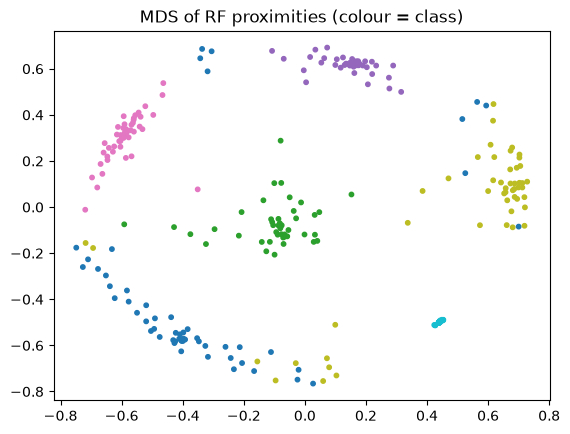

In [8]:
leaves = rf_lc.apply(Xl_te.iloc[:300])                                    # (samples, trees): leaf index
prox = (leaves[:, None, :] == leaves[None, :, :]).mean(-1)
from sklearn.manifold import MDS
emb = MDS(n_components=2, metric="precomputed", random_state=0, n_init=1, init="random").fit_transform(1 - prox)
cats = pd.Categorical(yl_te.iloc[:300])
plt.scatter(*emb.T, c=cats.codes, cmap="tab10", s=10)
plt.title("MDS of RF proximities (colour = class)"); plt.show()

### Quantile Regression Forests (prediction intervals)
A regression forest's leaves hold training targets. Instead of averaging them, take their **empirical quantiles** (Meinshausen, 2006). A simple approximation: collect, for each test sample, the training targets sharing its leaves across trees.

In [9]:
def qrf_predict(forest, X_train, y_train, X_new, qs=(0.05, 0.5, 0.95)):
    train_leaves = forest.apply(X_train); new_leaves = forest.apply(X_new); y_train = np.asarray(y_train)
    out = []
    for nl in new_leaves:
        w = np.zeros(len(y_train))
        for t in range(train_leaves.shape[1]):
            same = train_leaves[:, t] == nl[t]; w[same] += 1 / same.sum()
        order = np.argsort(y_train); cw = np.cumsum(w[order]) / w.sum()
        out.append([y_train[order][np.searchsorted(cw, q)] for q in qs])
    return np.array(out)

Xq_tr, Xq_te, yq_tr, yq_te = train_test_split(Xr, agb, test_size=0.2, random_state=1)
rf_q = RandomForestRegressor(200, min_samples_leaf=5, random_state=0, n_jobs=-1).fit(Xq_tr, yq_tr)
Q = qrf_predict(rf_q, Xq_tr, yq_tr, Xq_te.iloc[:300])
cover = np.mean((yq_te.values[:300] >= Q[:, 0]) & (yq_te.values[:300] <= Q[:, 2]))
print(f"90% prediction-interval coverage on test data: {cover:.3f} | mean interval width {np.mean(Q[:, 2] - Q[:, 0]):.1f} t/ha")

90% prediction-interval coverage on test data: 0.923 | mean interval width 56.1 t/ha


## **Practice Problems**
1. Tune `max_features` and `min_samples_leaf` of the land-cover RF with OOB score (no CV needed). Report the best pair.
2. Compute **grouped** permutation importance for {NDVI, B8, B4} together vs each alone.
3. Compare RF and ExtraTrees on the biomass regression (CV R^2).
4. *(Advanced)* Use the RF proximity to flag the 10 test samples with the lowest average proximity to their own class. Are they misclassified more often?

In [10]:
# Solution 1
res = {(mf, l): RandomForestClassifier(300, max_features=mf, min_samples_leaf=l, oob_score=True, random_state=0, n_jobs=-1).fit(Xl_tr, yl_tr).oob_score_
       for mf in ["sqrt", 0.33, 0.6] for l in [1, 3, 10]}
print("best (max_features, min_samples_leaf):", max(res, key=res.get), round(max(res.values()), 4))
# Solution 2
def grouped_perm(model, X, y, cols, n_rep=10):
    base = model.score(X, y); drops = []
    for _ in range(n_rep):
        Xp = X.copy(); idx = rng.permutation(len(X)); Xp[cols] = X[cols].values[idx]; drops.append(base - model.score(Xp, y))
    return np.mean(drops)
for cols in [["NDVI"], ["B8"], ["B4"], ["NDVI", "B8", "B4"]]:
    print(cols, round(grouped_perm(rf_lc, Xl_te, yl_te, cols), 4))
# Solution 3
from sklearn.ensemble import ExtraTreesRegressor
for nm, m in [("RF", RandomForestRegressor(300, random_state=0, n_jobs=-1)), ("ET", ExtraTreesRegressor(300, random_state=0, n_jobs=-1))]:
    print(nm, cross_val_score(m, Xr, agb, cv=5).mean().round(4))
# Solution 4
yt = yl_te.iloc[:300].values; pred = rf_lc.predict(Xl_te.iloc[:300])
own = np.array([prox[i, yt == yt[i]].mean() for i in range(300)])
low = np.argsort(own)[:10]
print(f"error rate among 10 least-typical samples: {np.mean(pred[low] != yt[low]):.2f} | overall: {np.mean(pred != yt):.3f}")

best (max_features, min_samples_leaf): (0.6, 1) 0.9732


['NDVI'] 0.0047


['B8'] 0.0033


['B4'] 0.0064


['NDVI', 'B8', 'B4'] 0.0346


RF 0.9727


ET 0.9724
error rate among 10 least-typical samples: 0.50 | overall: 0.033


## **Key References**
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32.
- Geurts, P., Ernst, D., & Wehenkel, L. (2006). Extremely randomized trees. *Machine Learning*, 63(1), 3-42.
- Meinshausen, N. (2006). Quantile regression forests. *JMLR*, 7, 983-999.
- Belgiu, M., & Dragut, L. (2016). Random forest in remote sensing: A review of applications and future directions. *ISPRS Journal of Photogrammetry and Remote Sensing*, 114, 24-31.
- Probst, P., Wright, M. N., & Boulesteix, A.-L. (2019). Hyperparameters and tuning strategies for random forest. *WIREs Data Mining and Knowledge Discovery*, 9(3), e1301.
- Strobl, C., Boulesteix, A.-L., Kneib, T., Augustin, T., & Zeileis, A. (2008). Conditional variable importance for random forests. *BMC Bioinformatics*, 9, 307.